# Chess Cheating Detection — Population PH on cp_loss (v7)

Each game side is a point in R^30 using cp_loss only.
Short games are **mean-padded** so padding doesn't look like perfect engine play.

Two approaches compared:
- **Raw**: ripser on R^30 vectors directly
- **UMAP**: project to 3D first, then ripser

Cheating and honest run as separate point clouds.

```
pip install python-chess stockfish ripser umap-learn scikit-learn pandas numpy matplotlib
```

## 0. Config

In [11]:
STOCKFISH_PATH    = r"./stockfish.exe"
STOCKFISH_DEPTH   = 12
TOP_N_MOVES_RANK  = 10
MAX_GAMES         = 500
CSV_PATH          = "Games.csv"
CHEAT_DENSITY_MIN = 0.20
FIXED_MOVES       = 30
MAX_CLOUD_POINTS  = 500
UMAP_N_COMPONENTS = 3

## 1. Imports

In [12]:
import chess, chess.pgn, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from stockfish import Stockfish
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import umap
from ripser import ripser
print('All imports OK')

All imports OK


## 2. Feature Extraction

In [13]:
def get_cp_loss(sf, board, move):
    sf.set_fen_position(board.fen())
    top = sf.get_top_moves(TOP_N_MOVES_RANK)
    if not top:
        return None
    MATE_CAP = 1000
    def cp(m):
        if m.get('Centipawn') is not None:
            return max(-MATE_CAP, min(MATE_CAP, m['Centipawn']))
        return MATE_CAP if (m.get('Mate') or 0) > 0 else -MATE_CAP
    eval_before = cp(top[0])
    b2 = board.copy()
    b2.push(move)
    sf.set_fen_position(b2.fen())
    ta = sf.get_top_moves(1)
    eval_after = -cp(ta[0]) if ta else eval_before
    return max(0.0, eval_before - eval_after)


def extract_cp_loss_vector(pgn_string, sf, color, fixed_moves=FIXED_MOVES):
    """
    Fixed-length cp_loss vector, shape (fixed_moves,).
    Short games are mean-padded (not zero-padded).
    """
    try:
        game = chess.pgn.read_game(io.StringIO(pgn_string))
    except Exception:
        return None
    if game is None:
        return None
    board = game.board()
    seq   = []
    for node in game.mainline():
        move = node.move
        if board.turn == color:
            loss = get_cp_loss(sf, board, move)
            seq.append(loss if loss is not None else 0.0)
            if len(seq) >= fixed_moves:
                break
        board.push(move)
    if len(seq) < 5:
        return None
    if len(seq) < fixed_moves:
        game_mean = float(np.mean(seq))
        seq += [game_mean] * (fixed_moves - len(seq))
    return np.array(seq, dtype=np.float32)


print('Extraction functions defined.')

Extraction functions defined.


## 3. Build Dataset

In [14]:
def count_color_moves(pgn_string, color):
    try:
        game = chess.pgn.read_game(io.StringIO(pgn_string))
    except Exception:
        return 0
    if game is None:
        return 0
    board, n = game.board(), 0
    for node in game.mainline():
        if board.turn == color:
            n += 1
        board.push(node.move)
    return n


def build_dataset(csv_path, sf, max_games=None, cheat_density_min=CHEAT_DENSITY_MIN):
    df = pd.read_csv(csv_path)
    is_clean_w = df['Liste cheat white'].apply(lambda x: '1' not in str(x))
    is_clean_b = df['Liste cheat black'].apply(lambda x: '1' not in str(x))
    df_clean = df[ is_clean_w & is_clean_b].reset_index(drop=True)
    df_cheat = df[~(is_clean_w & is_clean_b)].reset_index(drop=True)
    print('Dataset: {} clean, {} cheating games'.format(len(df_clean), len(df_cheat)))

    print('Pass 1: scanning cheat density...')
    candidates = []
    for idx, row in df_cheat.iterrows():
        for color, cheat_str in [
            (chess.WHITE, str(row['Liste cheat white'])),
            (chess.BLACK, str(row['Liste cheat black'])),
        ]:
            if '1' not in cheat_str:
                continue
            n_color = count_color_moves(row['Game'], color)
            density = cheat_str.count('1') / n_color if n_color > 0 else 0.0
            if density >= cheat_density_min:
                candidates.append((row, color, round(density, 4)))
        if idx % 50 == 0:
            print('  {}/{} scanned, {} candidates...'.format(idx, len(df_cheat), len(candidates)))

    n = len(candidates)
    if max_games:
        n = min(n, max_games // 2)
        candidates = candidates[:n]
    print('Cheating sides: {}'.format(len(candidates)))

    df_clean_sample = df_clean.sample(min(len(df_clean), n), random_state=42)
    rows, labels = [], []

    print('Pass 2a: {} cheating sides...'.format(len(candidates)))
    for i, (row, color, _) in enumerate(candidates):
        vec = extract_cp_loss_vector(row['Game'], sf, color)
        if vec is not None:
            rows.append(vec)
            labels.append(1)
        if i % 10 == 0:
            print('  {}/{}...'.format(i, len(candidates)))

    n_cheat = sum(labels)
    print('Cheating extracted: {}'.format(n_cheat))

    print('Pass 2b: honest sides (target={})...'.format(n_cheat))
    n_honest = 0
    for i, (_, row) in enumerate(df_clean_sample.iterrows()):
        if n_honest >= n_cheat:
            break
        for color in [chess.WHITE, chess.BLACK]:
            if n_honest >= n_cheat:
                break
            vec = extract_cp_loss_vector(row['Game'], sf, color)
            if vec is not None:
                rows.append(vec)
                labels.append(0)
                n_honest += 1
        if i % 10 == 0:
            print('  {}/{} games, {} honest so far...'.format(i, len(df_clean_sample), n_honest))

    X      = np.array(rows,   dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    print('Final: {}  {}cheat / {}honest'.format(X.shape, labels.sum(), (labels==0).sum()))
    return X, labels

In [15]:
print('Initializing Stockfish...')
sf = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
sf.update_engine_parameters({'Threads': 2, 'Hash': 128})
print('Stockfish ready.')

X, labels = build_dataset(CSV_PATH, sf, max_games=MAX_GAMES)

np.save('X_cploss_v7.npy', X)
np.save('labels_v7.npy',   labels)
print('Saved.')

Initializing Stockfish...
Stockfish ready.
Dataset: 9374 clean, 39558 cheating games
Pass 1: scanning cheat density...
  0/39558 scanned, 2 candidates...
  50/39558 scanned, 77 candidates...
  100/39558 scanned, 139 candidates...
  150/39558 scanned, 216 candidates...
  200/39558 scanned, 283 candidates...
  250/39558 scanned, 352 candidates...
  300/39558 scanned, 431 candidates...
  350/39558 scanned, 497 candidates...
  400/39558 scanned, 573 candidates...
  450/39558 scanned, 643 candidates...
  500/39558 scanned, 709 candidates...
  550/39558 scanned, 777 candidates...
  600/39558 scanned, 843 candidates...
  650/39558 scanned, 912 candidates...
  700/39558 scanned, 980 candidates...
  750/39558 scanned, 1047 candidates...
  800/39558 scanned, 1114 candidates...
  850/39558 scanned, 1181 candidates...
  900/39558 scanned, 1249 candidates...
  950/39558 scanned, 1318 candidates...
  1000/39558 scanned, 1386 candidates...
  1050/39558 scanned, 1453 candidates...
  1100/39558 scanned

### (Optional) Reload

In [16]:
# X      = np.load('X_cploss_v7.npy')
# labels = np.load('labels_v7.npy')
# print(X.shape, labels.shape)

## 4. Data Inspection

Heatmap sorted by mean cp_loss. Mean-padded games should show no zero tail on the right edge.

Zero-tail length: mean=0.6  max=10
(Should be ~0 with mean-padding)


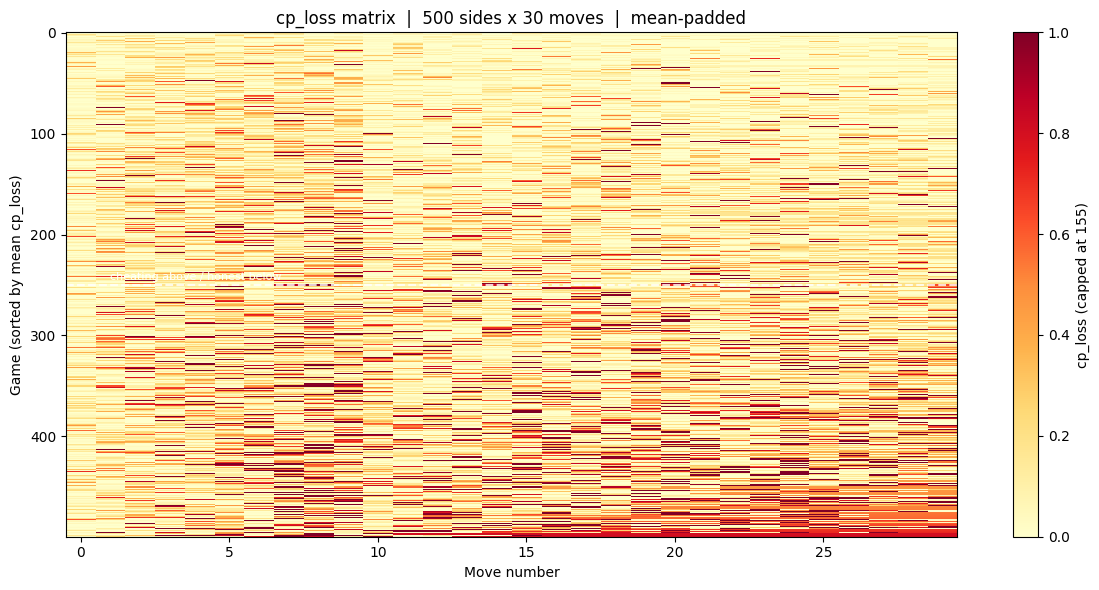

In [17]:
# Verify mean-padding: zero-tail should be near zero
zero_tail = []
for row in X:
    t = 0
    for v in reversed(row):
        if v < 0.5: t += 1
        else: break
    zero_tail.append(t)
print('Zero-tail length: mean={:.1f}  max={}'.format(np.mean(zero_tail), np.max(zero_tail)))
print('(Should be ~0 with mean-padding)')

order      = np.argsort(X.mean(axis=1))
X_sorted   = X[order]
lab_sorted = labels[order]
cap        = float(np.percentile(X, 95))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.clip(X_sorted / cap, 0, 1),
               aspect='auto', cmap='YlOrRd', vmin=0, vmax=1,
               interpolation='nearest')
plt.colorbar(im, ax=ax, label='cp_loss (capped at {:.0f})'.format(cap))
boundary = int((lab_sorted == 1).sum())
ax.axhline(boundary, color='white', lw=1.5, linestyle='--', alpha=0.8)
ax.text(1, boundary - 5, 'cheating above / honest below',
        color='white', fontsize=8)
ax.set_xlabel('Move number')
ax.set_ylabel('Game (sorted by mean cp_loss)')
ax.set_title('cp_loss matrix  |  {} sides x {} moves  |  mean-padded'.format(X.shape[0], FIXED_MOVES))
plt.tight_layout()
plt.savefig('cploss_heatmap_v7.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Normalise and Prepare Clouds

In [18]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

rng = np.random.default_rng(42)

def subsample(pts, cap=MAX_CLOUD_POINTS):
    if len(pts) > cap:
        return pts[rng.choice(len(pts), cap, replace=False)]
    return pts

cheat_raw_s  = subsample(X_norm[labels == 1])
honest_raw_s = subsample(X_norm[labels == 0])

# Auto-calibrate threshold from pairwise distances
sample_idx = rng.choice(len(X_norm), min(60, len(X_norm)), replace=False)
dists = pairwise_distances(X_norm[sample_idx]).ravel()
dists = dists[dists > 0]
thresh_raw = float(np.percentile(dists, 75))
print('Raw cloud sizes: cheat={}, honest={}'.format(len(cheat_raw_s), len(honest_raw_s)))
print('Pairwise dist p75 (raw) = {:.3f}  -> thresh_raw'.format(thresh_raw))

Raw cloud sizes: cheat=250, honest=250
Pairwise dist p75 (raw) = 9.332  -> thresh_raw


## 6. Plotting Functions

In [19]:
def plot_pd_pair(dgms_c, dgms_h, thresh, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for col, (dgms, name, color) in enumerate([
        (dgms_c, 'Cheating', 'tomato'),
        (dgms_h, 'Honest',   'steelblue'),
    ]):
        for row, dim in enumerate([0, 1]):
            ax  = axes[row, col]
            pts = dgms[dim].copy()
            fin = pts[pts[:, 1] < np.inf]
            inf = pts[pts[:, 1] == np.inf]
            vmax = fin[:, 1].max() * 1.05 if len(fin) > 0 else thresh
            if len(fin) > 0:
                pers = fin[:, 1] - fin[:, 0]
                sc = ax.scatter(fin[:, 0], fin[:, 1], c=pers, cmap='YlOrRd',
                                s=22, alpha=0.85, vmin=0, vmax=pers.max(),
                                edgecolors='grey', linewidths=0.2, zorder=3)
                plt.colorbar(sc, ax=ax, label='Persistence', shrink=0.8)
            if len(inf) > 0:
                ax.scatter(inf[:, 0], [vmax * 0.96] * len(inf),
                           marker='^', color=color, s=40, alpha=0.8,
                           label='{} inf'.format(len(inf)), zorder=4)
                ax.legend(fontsize=8)
            ax.plot([0, vmax], [0, vmax], 'k--', alpha=0.3, lw=0.8)
            ax.set_xlim([0, vmax]); ax.set_ylim([0, vmax])
            ax.set_xlabel('Birth', fontsize=9)
            ax.set_ylabel('Death', fontsize=9)
            ax.set_title('{} - H{}'.format(name, dim), color=color,
                         fontsize=10, fontweight='bold')
            ax.text(0.98, 0.04, '{} finite  {} inf'.format(len(fin), len(inf)),
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=8, color='gray')
    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    return fig


def plot_barcode_pair(dgms_c, dgms_h, thresh, title):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for col, (dgms, name, color) in enumerate([
        (dgms_c, 'Cheating', 'tomato'),
        (dgms_h, 'Honest',   'steelblue'),
    ]):
        for row, dim in enumerate([0, 1]):
            ax  = axes[row, col]
            pts = dgms[dim].copy()
            fin = pts[pts[:, 1] < np.inf]
            inf_mask = pts[:, 1] == np.inf
            disp = pts.copy()
            disp[inf_mask, 1] = thresh * 0.97
            pers  = disp[:, 1] - disp[:, 0]
            order = np.argsort(pers)[::-1]
            disp, pers, inf_mask = disp[order], pers[order], inf_mask[order]
            for i, ((birth, death), p, is_inf) in enumerate(zip(disp, pers, inf_mask)):
                alpha = 0.35 + 0.6 * (p / pers[0]) if pers[0] > 0 else 0.5
                ax.barh(i, death - birth, left=birth, height=0.8,
                        color=color, alpha=alpha,
                        linestyle='--' if is_inf else '-',
                        edgecolor=color if is_inf else 'none',
                        linewidth=0.8 if is_inf else 0)
            ax.set_xlim([0, thresh])
            ax.set_yticks([])
            ax.set_xlabel('Filtration e', fontsize=9)
            ax.set_title('{} - H{}  ({} finite, {} inf)'.format(
                name, dim, len(fin), int(inf_mask.sum())),
                color=color, fontsize=9, fontweight='bold')
    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    return fig


print('Plotting functions defined.')

Plotting functions defined.


## 7. PH on Raw R^30 Vectors

In [20]:
print('Running ripser on raw R^{} clouds...'.format(FIXED_MOVES))
dgms_raw_c = ripser(cheat_raw_s,  maxdim=1, thresh=thresh_raw)['dgms']
dgms_raw_h = ripser(honest_raw_s, maxdim=1, thresh=thresh_raw)['dgms']
print('Done.')

for name, dgms in [('Cheating', dgms_raw_c), ('Honest', dgms_raw_h)]:
    for dim in [0, 1]:
        fin  = dgms[dim][dgms[dim][:, 1] < np.inf]
        inf  = int((dgms[dim][:, 1] == np.inf).sum())
        pers = (fin[:, 1] - fin[:, 0]) if len(fin) > 0 else np.array([0.0])
        print('  {} H{}: {} finite  {} inf  max_pers={:.3f}'.format(
              name, dim, len(fin), inf, pers.max()))

Running ripser on raw R^30 clouds...
Done.
  Cheating H0: 246 finite  4 inf  max_pers=7.766
  Cheating H1: 47 finite  0 inf  max_pers=0.417
  Honest H0: 243 finite  7 inf  max_pers=8.936
  Honest H1: 69 finite  0 inf  max_pers=0.619


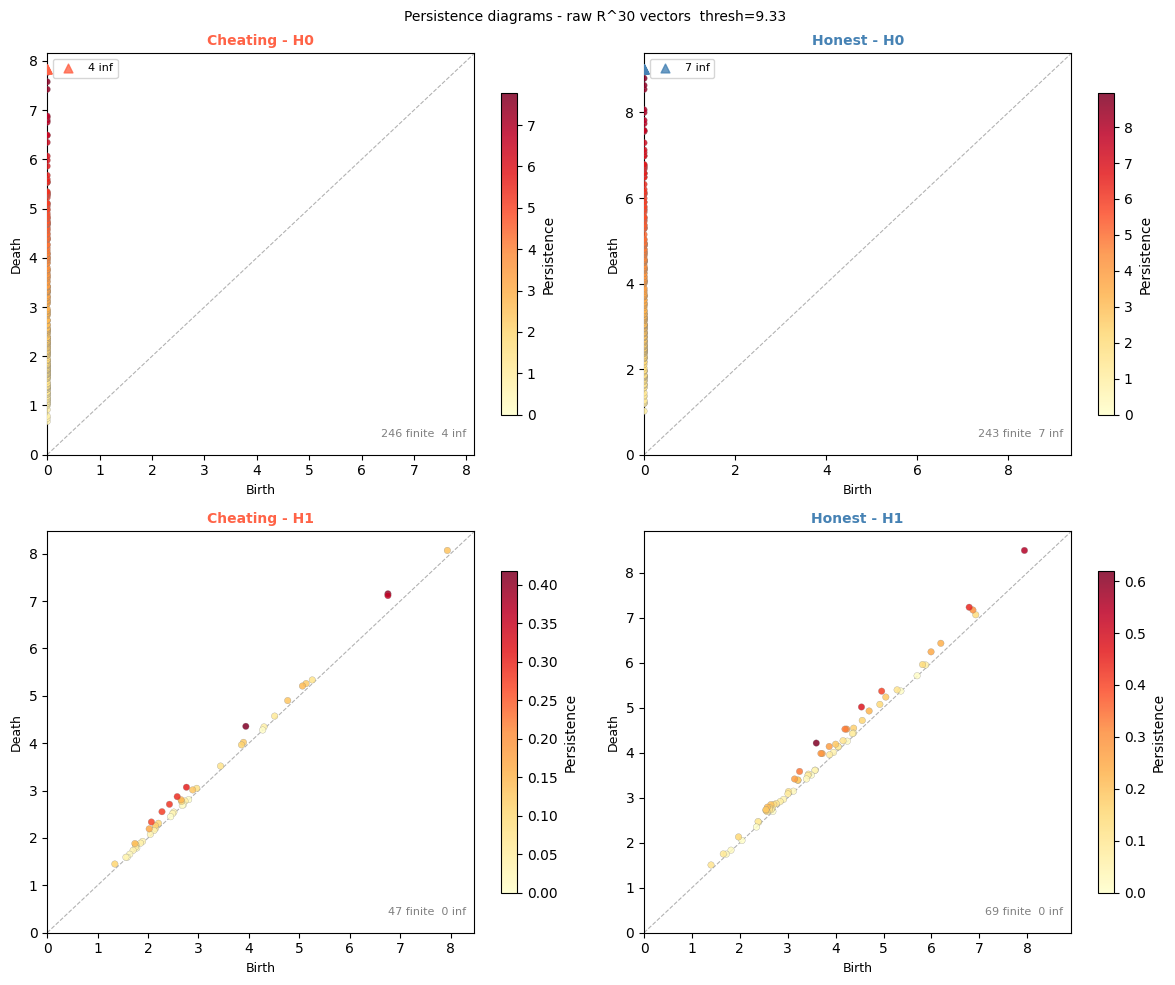

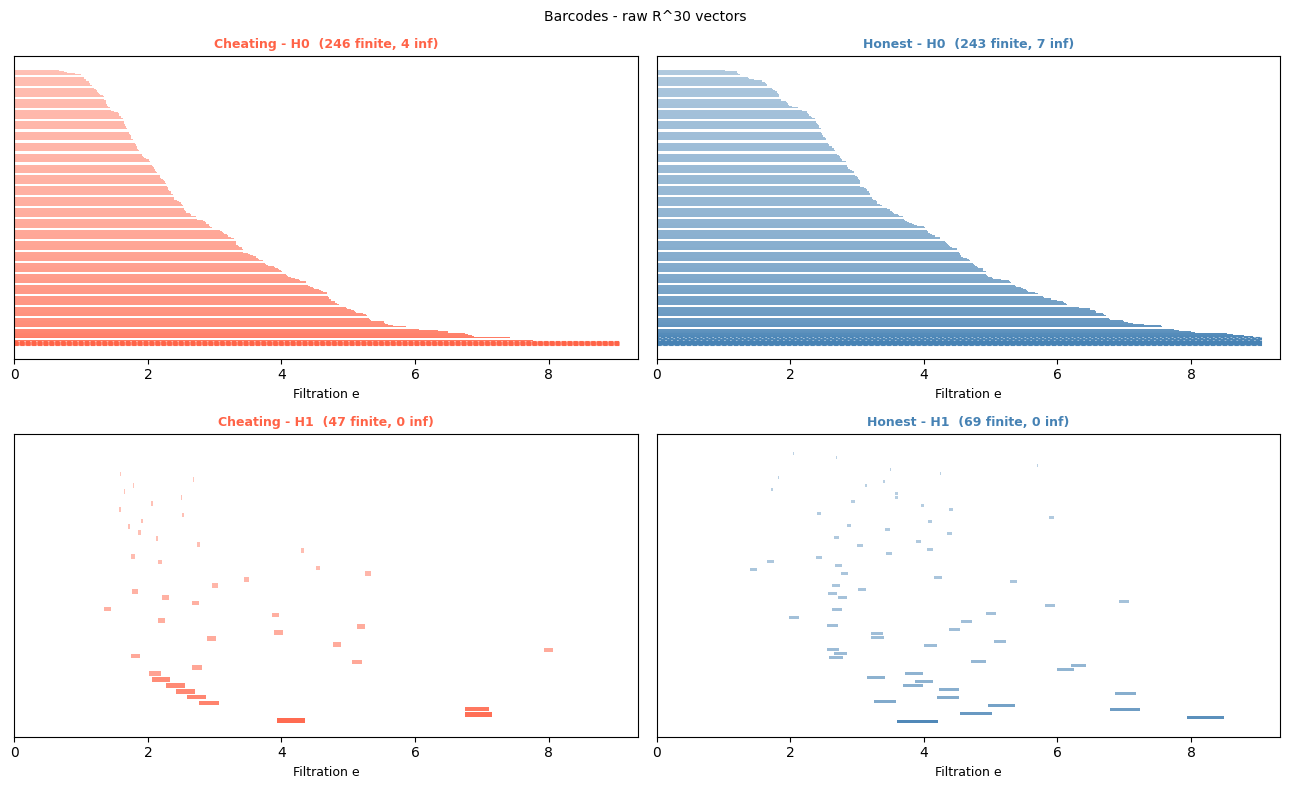

In [21]:
fig = plot_pd_pair(dgms_raw_c, dgms_raw_h, thresh_raw,
                  'Persistence diagrams - raw R^{} vectors  thresh={:.2f}'.format(
                   FIXED_MOVES, thresh_raw))
plt.savefig('pd_raw_v7.png', dpi=150, bbox_inches='tight')
plt.show()

fig = plot_barcode_pair(dgms_raw_c, dgms_raw_h, thresh_raw,
                       'Barcodes - raw R^{} vectors'.format(FIXED_MOVES))
plt.savefig('barcodes_raw_v7.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. PH on UMAP-Reduced Vectors (R^3)

Project to 3D with UMAP then run ripser. In low dimensions pairwise distances are meaningful and H1 features are more interpretable.

The scatter plot below shows whether the classes visually separate — if they do, PH has real structure to find.

Fitting UMAP (500, 30) -> 3D...
X_umap shape: (500, 3)
UMAP cloud sizes: cheat=250, honest=250
Pairwise dist p75 (UMAP) = 3.201  -> thresh_u


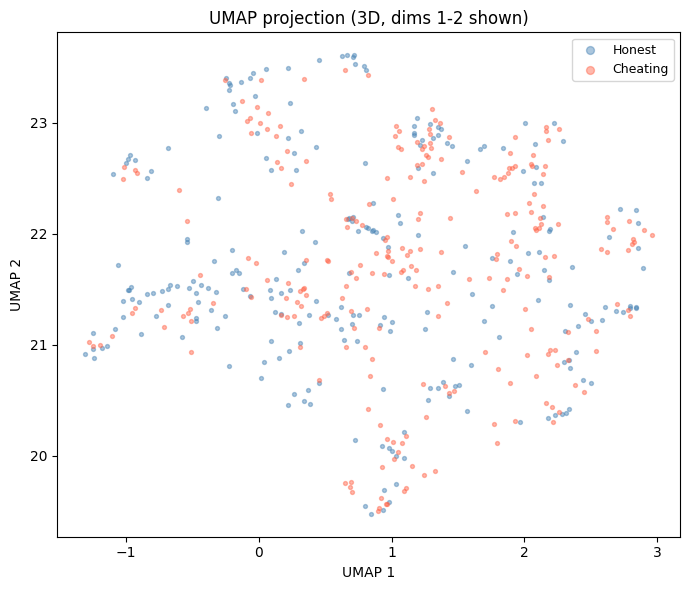

In [22]:
print('Fitting UMAP {} -> {}D...'.format(X_norm.shape, UMAP_N_COMPONENTS))
reducer = umap.UMAP(n_components=UMAP_N_COMPONENTS, random_state=42, n_neighbors=15)
X_umap  = reducer.fit_transform(X_norm)
print('X_umap shape:', X_umap.shape)

cheat_umap_s  = subsample(X_umap[labels == 1])
honest_umap_s = subsample(X_umap[labels == 0])

dists_u = pairwise_distances(
    X_umap[rng.choice(len(X_umap), min(60, len(X_umap)), replace=False)]
).ravel()
dists_u   = dists_u[dists_u > 0]
thresh_u  = float(np.percentile(dists_u, 75))
print('UMAP cloud sizes: cheat={}, honest={}'.format(len(cheat_umap_s), len(honest_umap_s)))
print('Pairwise dist p75 (UMAP) = {:.3f}  -> thresh_u'.format(thresh_u))

# Scatter plot (dims 1-2)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_umap[labels==0, 0], X_umap[labels==0, 1],
           s=8, alpha=0.45, color='steelblue', label='Honest')
ax.scatter(X_umap[labels==1, 0], X_umap[labels==1, 1],
           s=8, alpha=0.45, color='tomato',    label='Cheating')
ax.set_title('UMAP projection ({}D, dims 1-2 shown)'.format(UMAP_N_COMPONENTS))
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('umap_scatter_v7.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print('Running ripser on UMAP-reduced clouds...')
dgms_umap_c = ripser(cheat_umap_s,  maxdim=1, thresh=thresh_u)['dgms']
dgms_umap_h = ripser(honest_umap_s, maxdim=1, thresh=thresh_u)['dgms']
print('Done.')

for name, dgms in [('Cheating', dgms_umap_c), ('Honest', dgms_umap_h)]:
    for dim in [0, 1]:
        fin  = dgms[dim][dgms[dim][:, 1] < np.inf]
        inf  = int((dgms[dim][:, 1] == np.inf).sum())
        pers = (fin[:, 1] - fin[:, 0]) if len(fin) > 0 else np.array([0.0])
        print('  {} H{}: {} finite  {} inf  max_pers={:.3f}'.format(
              name, dim, len(fin), inf, pers.max()))

Running ripser on UMAP-reduced clouds...
Done.
  Cheating H0: 249 finite  1 inf  max_pers=0.956
  Cheating H1: 69 finite  0 inf  max_pers=0.560
  Honest H0: 249 finite  1 inf  max_pers=1.160
  Honest H1: 57 finite  0 inf  max_pers=0.497


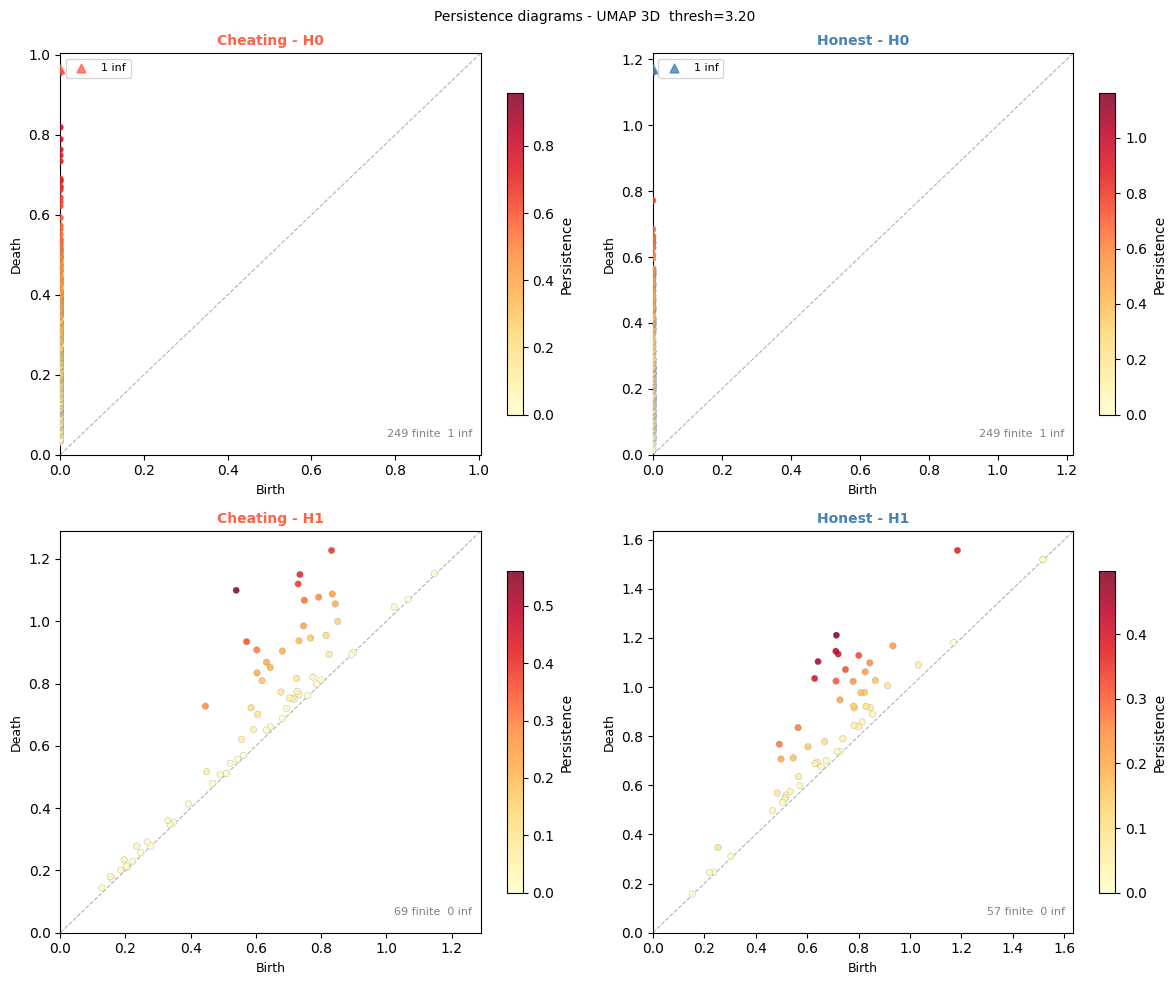

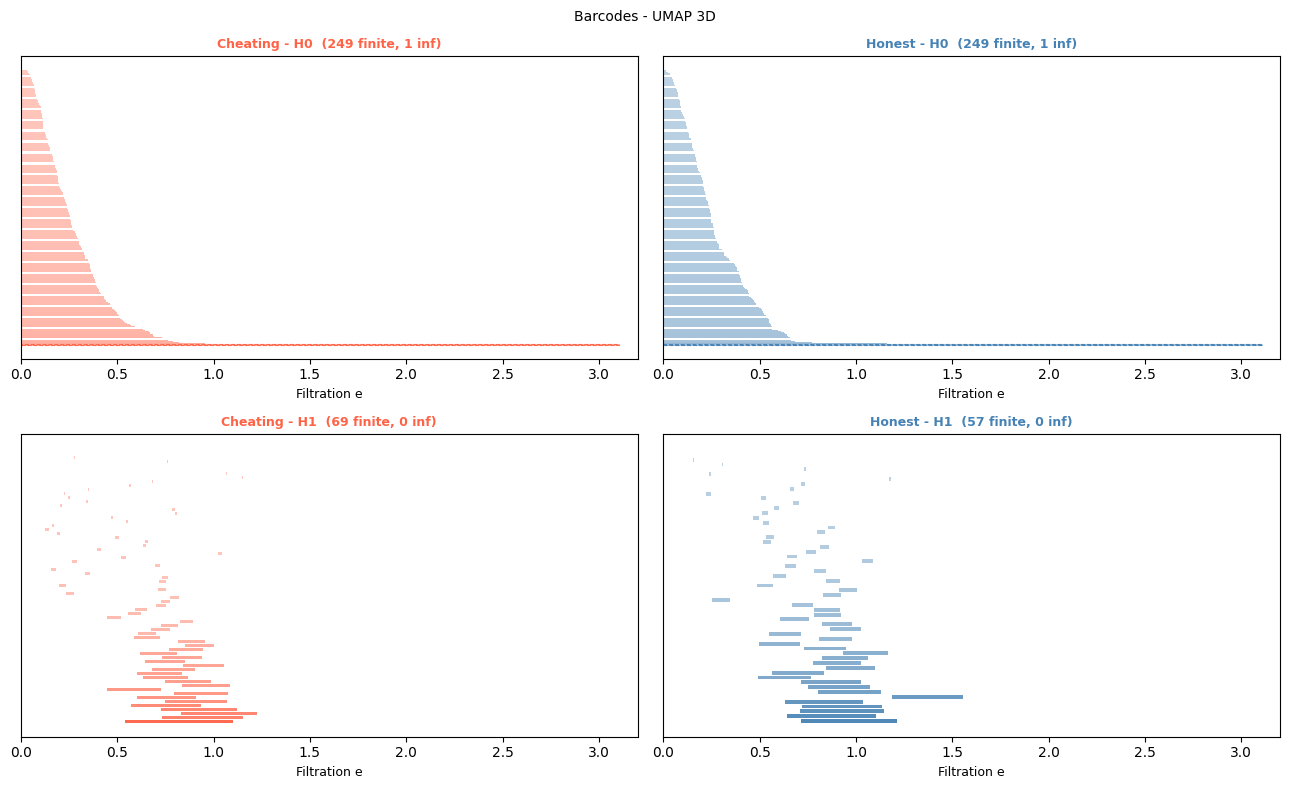

In [24]:
fig = plot_pd_pair(dgms_umap_c, dgms_umap_h, thresh_u,
                  'Persistence diagrams - UMAP {}D  thresh={:.2f}'.format(
                   UMAP_N_COMPONENTS, thresh_u))
plt.savefig('pd_umap_v7.png', dpi=150, bbox_inches='tight')
plt.show()

fig = plot_barcode_pair(dgms_umap_c, dgms_umap_h, thresh_u,
                       'Barcodes - UMAP {}D'.format(UMAP_N_COMPONENTS))
plt.savefig('barcodes_umap_v7.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [25]:
print('=' * 60)
print('SUMMARY (v7)')
print('=' * 60)
print('  Matrix : {}  (game sides x moves)'.format(X.shape))
print('  Feature: cp_loss only, mean-padded')
print('  Cheat  : {}'.format((labels==1).sum()))
print('  Honest : {}'.format((labels==0).sum()))
print('  thresh_raw  = {:.3f}'.format(thresh_raw))
print('  thresh_umap = {:.3f}'.format(thresh_u))
print()
print('         H0_fin H0_inf  H1_fin H1_inf  H1_max')
for tag, dc, dh in [('Raw ', dgms_raw_c, dgms_raw_h),
                    ('UMAP', dgms_umap_c, dgms_umap_h)]:
    for name, dgms in [('Cheat', dc), ('Honest', dh)]:
        h0f = int((dgms[0][:, 1] < np.inf).sum())
        h0i = int((dgms[0][:, 1] == np.inf).sum())
        h1  = dgms[1][dgms[1][:, 1] < np.inf]
        h1f = len(h1)
        h1i = int((dgms[1][:, 1] == np.inf).sum())
        h1m = float((h1[:, 1] - h1[:, 0]).max()) if h1f > 0 else 0.0
        print('  {} {}   {:5d}  {:5d}  {:5d}  {:5d}  {:.3f}'.format(
              tag, name, h0f, h0i, h1f, h1i, h1m))

SUMMARY (v7)
  Matrix : (500, 30)  (game sides x moves)
  Feature: cp_loss only, mean-padded
  Cheat  : 250
  Honest : 250
  thresh_raw  = 9.332
  thresh_umap = 3.201

         H0_fin H0_inf  H1_fin H1_inf  H1_max
  Raw  Cheat     246      4     47      0  0.417
  Raw  Honest     243      7     69      0  0.619
  UMAP Cheat     249      1     69      0  0.560
  UMAP Honest     249      1     57      0  0.497
